#  Q1: Problem Context and Dataset Justification

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from joblib import Parallel, delayed
import multiprocessing

#Load Dataset

In [8]:

df = pd.read_csv('Historical_Tropical_Storm_Tracks.csv')
print("Data Loaded. Shape:", df.shape)
df.head()

Data Loaded. Shape: (59228, 15)


,index,FID,YEAR,MONTH,DAY,AD_TIME,BTID,NAME,LAT,LONG,WIND_KTS,PRESSURE,CAT,BASIN,Shape_Leng
0,0,2001,1957,8,8,1800Z,63,NOTNAMED,22.5,-140.0,50,0,TS,Eastern Pacific,1.140175
1,1,2002,1961,10,3,1200Z,116,PAULINE,22.1,-140.2,45,0,TS,Eastern Pacific,1.166190
2,2,2003,1962,8,29,0600Z,124,C,18.0,-140.0,45,0,TS,Eastern Pacific,2.102380
3,3,2004,1967,7,14,0600Z,168,DENISE,16.6,-139.5,45,0,TS,Eastern Pacific,2.121320
4,4,2005,1972,8,16,1200Z,251,DIANA,18.5,-139.8,70,0,H1,Eastern Pacific,1.702939


# Preprocessing

In [9]:

df = df.dropna()
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Label encode categorical columns
label_cols = ['NAME', 'CAT', 'BASIN']
for col in label_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Create binary target: Severity based on WIND_KTS
SEVERE_THRESHOLD = 100
df['Severity'] = df['WIND_KTS'].apply(lambda x: 1 if x >= SEVERE_THRESHOLD else 0)

# Drop non-useful columns
X = df.drop(columns=['index', 'FID', 'BTID', 'AD_TIME', 'Severity'], errors='ignore')
y = df['Severity']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split

In [10]:

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Non-parallel Random Forest Training

Non-parallel Accuracy: 1.0
Training Time (Non-Parallel): 3.18 s


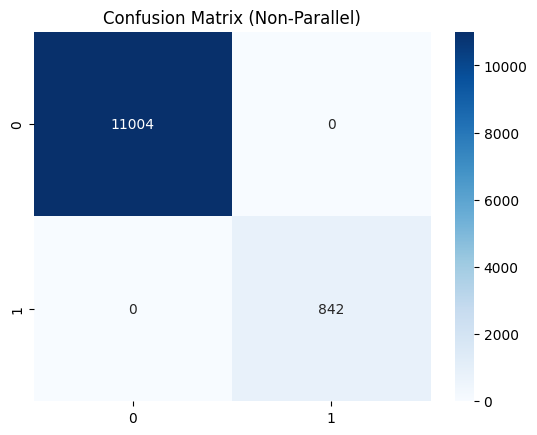

In [17]:

start_time = time.time()
model = RandomForestClassifier(n_estimators=100, n_jobs=1)
model.fit(X_train, y_train)
end_time = time.time()

non_parallel_time = end_time - start_time  # ✅ Store it for comparison

y_pred = model.predict(X_test)
print("Non-parallel Accuracy:", accuracy_score(y_test, y_pred))
print("Training Time (Non-Parallel):", round(non_parallel_time, 2), "s")

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Non-Parallel)")
plt.show()

# Parallel Cross-Validation

In [18]:


# ⚡ Parallel Cross-Validation
def parallel_cv(X, y, model_class, cv=5):
    num_cores = multiprocessing.cpu_count()
    print(f"Running parallel CV with {num_cores} cores...")

    def single_run(seed):
        clf = model_class(n_estimators=100, random_state=seed, n_jobs=-1)
        return cross_val_score(clf, X, y, cv=cv).mean()

    start = time.time()
    scores = Parallel(n_jobs=num_cores)(delayed(single_run)(i) for i in range(num_cores))
    end = time.time()

    parallel_time = end - start  # ✅ Store for comparison
    print("Parallel CV Time:", round(parallel_time, 2), "seconds")
    print("CV Mean Accuracy:", round(np.mean(scores), 4))

    return parallel_time

# Capture parallel time
parallel_time = parallel_cv(X_scaled, y, RandomForestClassifier)


Running parallel CV with 12 cores...
Parallel CV Time: 15.09 seconds
CV Mean Accuracy: 1.0


1. Feature Distribution (Bar Chart)

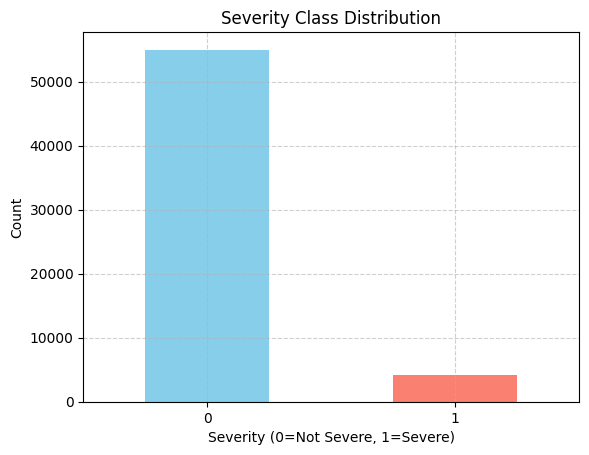

In [13]:
# Bar chart for target variable
severity_counts = df['Severity'].value_counts()
severity_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Severity Class Distribution')
plt.xlabel('Severity (0=Not Severe, 1=Severe)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


2. Correlation Heatmap

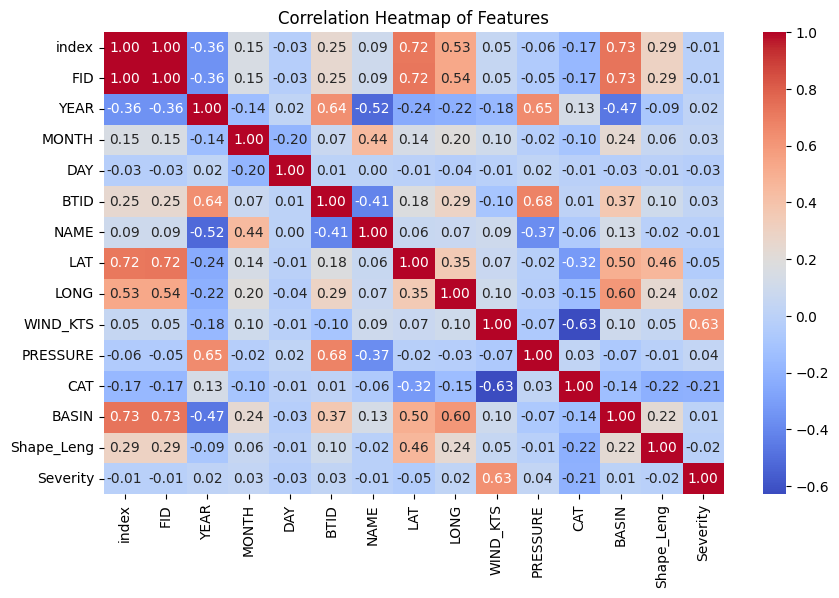

In [14]:
# Correlation matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.show()


🔹 3. Feature Importance (from RandomForest)

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_5400\2731478341.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


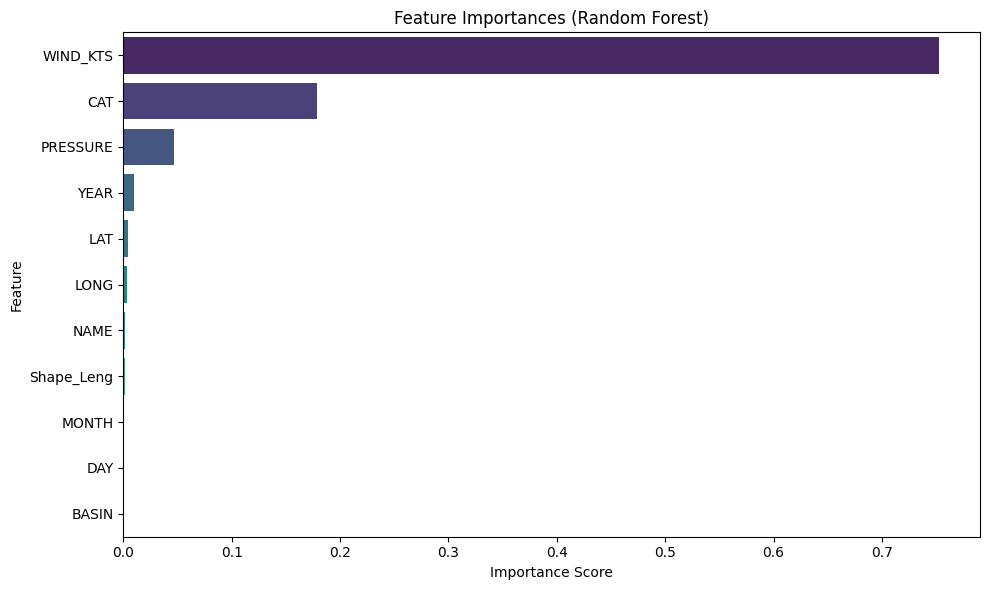

In [15]:
# Feature importance
importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


 4. Parallel vs Non-parallel Time Comparison

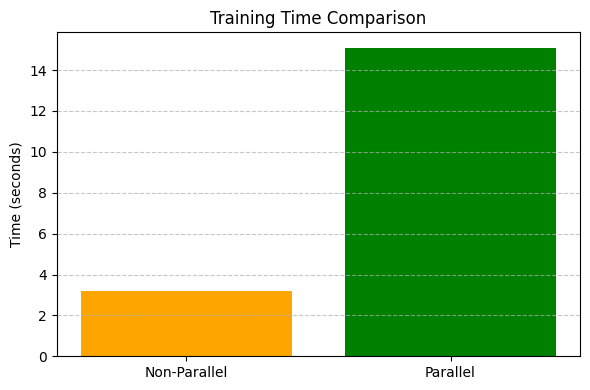

In [20]:
times = [non_parallel_time, parallel_time]
labels = ['Non-Parallel', 'Parallel']

plt.figure(figsize=(6, 4))
plt.bar(labels, times, color=['orange', 'green'])
plt.title('Training Time Comparison')
plt.ylabel('Time (seconds)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
